/tmp/ipykernel_17139/1642140863.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = cm.get_cmap('tab20', 20)  # Carrega o colormap com 20 cores


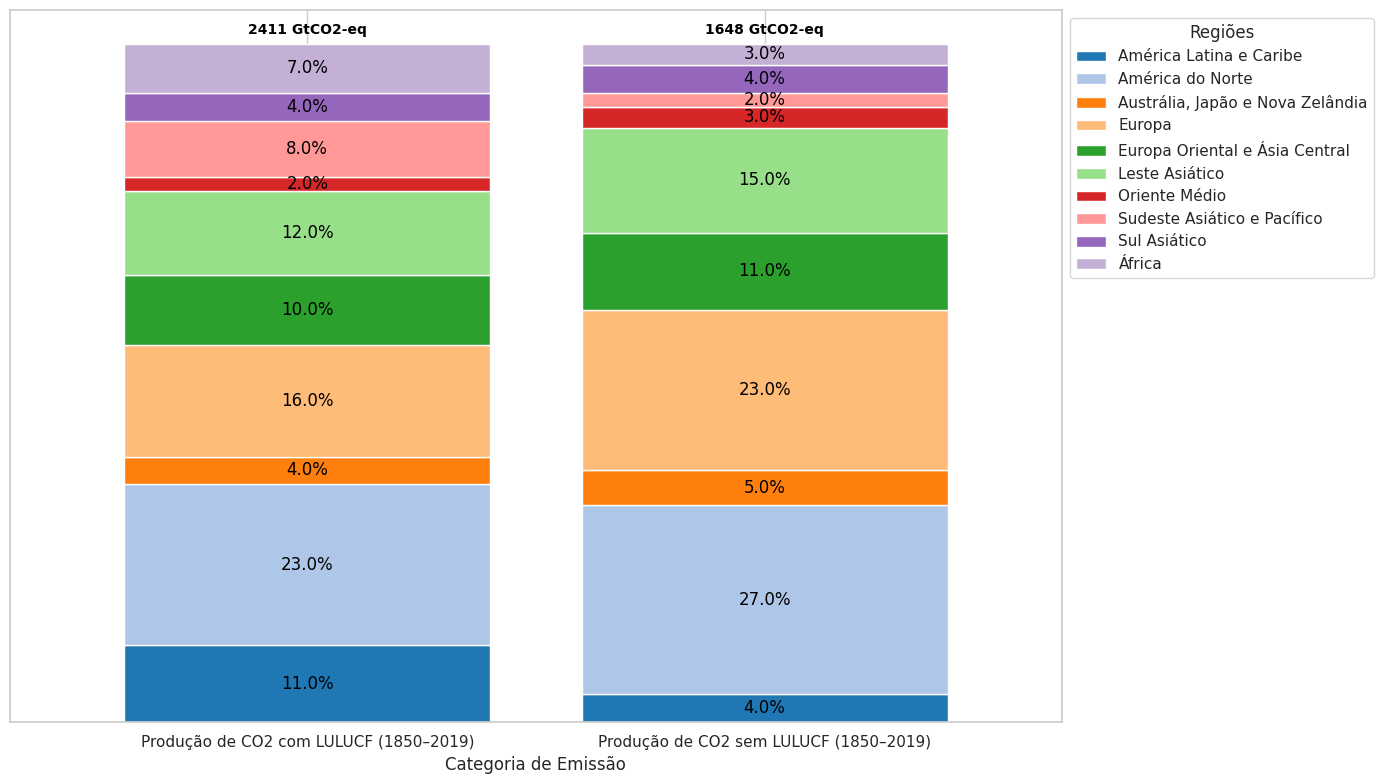

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# Dados (ajustados para incluir 0.4% e garantir ordem correta)
data = {
    'porcentagem': [
        3, 5, 15, 11, 23, 4, 3, 27, 2, 4,  # Sem LULUCF
        7, 4, 12, 10, 16, 11, 2, 23, 8, 4,  # Com LULUCF
    ],
    'regiao': [
        'África', 'Austrália, Japão e Nova Zelândia', 'Leste Asiático', 'Europa Oriental e Ásia Central', 'Europa', 'América Latina e Caribe', 'Oriente Médio', 'América do Norte', 'Sudeste Asiático e Pacífico', 'Sul Asiático',
        'África', 'Austrália, Japão e Nova Zelândia', 'Leste Asiático', 'Europa Oriental e Ásia Central', 'Europa', 'América Latina e Caribe', 'Oriente Médio', 'América do Norte', 'Sudeste Asiático e Pacífico', 'Sul Asiático'
    ],
    'LULUCF': [
        'Produção de CO2 sem LULUCF (1850–2019)', 
        *['Produção de CO2 sem LULUCF (1850–2019)'] * 9,
        'Produção de CO2 com LULUCF (1850–2019)', 
        *['Produção de CO2 com LULUCF (1850–2019)'] * 9
    ]
}

df = pd.DataFrame(data)
df_pivot = df.pivot(index='LULUCF', columns='regiao', values='porcentagem')

tab20 = cm.get_cmap('tab20', 20)  # Carrega o colormap com 20 cores
colors = [tab20(i) for i in range(10)]  # Seleciona as 10 primeiras cores

# Plotagem
sns.set_theme(style="whitegrid")
ax = df_pivot.plot(kind='bar', stacked=True, figsize=(14, 8), width=0.8, color=colors)

# Remover eixo Y
ax.yaxis.set_visible(False)

# Adicionar porcentagens dentro das barras
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # Ignorar segmentos vazios
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_y() + height / 2  # Posição vertical central do segmento
            ax.text(
                x, y, 
                f'{height:.1f}%',  # Formato: 1 casa decimal
                ha='center', 
                va='center', 
                color='black',
                fontsize=12
            )

# Ajustar título e legendas
plt.xlabel('Categoria de Emissão', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Regiões', bbox_to_anchor=(1, 1), loc='upper left')

labels_topo = ['2411 GtCO2-eq', '1648 GtCO2-eq']
for i, label in enumerate(labels_topo):
    # Calcular a altura total de cada barra (soma das porcentagens empilhadas)
    altura_total = df_pivot.iloc[i].sum()
    
    # Posição x (centro da barra) e y (topo da barra + offset)
    x = i  # Índice da barra (0 para a primeira, 1 para a segunda)
    y = altura_total + 1  # Offset de 1% para evitar sobreposição
    
    ax.text(
        x, y, 
        label, 
        ha='center', 
        va='bottom', 
        fontsize=10,
        color='black',
        weight='bold'
    )

# Print e salvar;
plt.tight_layout()
plt.savefig(
    '/home/juju/Documents/TCC/Nivel_TCC/docs/main/img/contrib_regiao.png',
    dpi=300,                  # Resolução da imagem
    bbox_inches='tight',      # Remove bordas em branco
    format='png'              # Formato desejado (opcional, inferido automaticamente)
)
plt.show()